# How many fixed-point bits do the spiking probabilities need?

The task is to represent the random walker's spiking probabilities as integer codes with an agreed scale, and measure how many bits give useful accuracy. Neuron states and walker counts remain integers. A probability controls whether a whole spike occurs; it does not create a fractional walker.

The main binary result: across nine specific cases, nearest rounding with F=15 fractional bits gives a largest average error of 0.928% and a largest peak error of 2.025%. With F=16, these fall to 0.341% and 0.853%. Our code format includes probability exactly 1, so these choices use 16 and 17 stored bits per probability, respectively. All stored probabilities use the same F in each experiment.

These numbers describe errors in expected populations, not the outcome of an individual random run. Float means the original, unrounded probabilities. We calculate expected populations directly to isolate the effect of rounding.

The binary results answer the bit-width question. Decimal rounding is kept as a supporting comparison, not a request for decimal arithmetic in hardware. The final section gives the binary choices and their conditions.

Follow four steps: build the probabilities, round them, calculate populations, compare answers. Start with one worked comparison, then repeat it for the listed cases. All experiments and saved outputs are included; no extra data files are needed.

## 1. Setup

Use Restart Kernel and Run All Cells to reproduce the results. You can also read the saved outputs without running anything.

The setup imports the libraries and defines two short helpers for printing tables. They only format the output; the model starts in section 2. No HTML or extra table library is needed.

On a new machine, use Python 3.13 and run:

```text
python -m pip install numpy matplotlib jupyterlab
python -m jupyterlab
```

Open this notebook in that Python environment. Tested with NumPy 2.5.3 and Matplotlib 3.11.1.


In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})


# Print readable tables. These helpers do not change the calculated results.
def show_table(headers, rows, title=None):
    if title:
        print("\n" + title)
    text_rows = [headers]
    for row in rows:
        text_rows.append([
            f"{value:.3f}" if isinstance(value, (float, np.floating)) else str(value)
            for value in row
        ])
    widths = [max(len(row[i]) for row in text_rows) for i in range(len(headers))]
    for row in text_rows:
        print(" | ".join(value.ljust(width) for value, width in zip(row, widths)))


def show_records(records, columns, headers, title=None):
    rows = [[record[column] for column in columns] for record in records]
    show_table(headers, rows, title)


## 2. Build the movement probabilities

A walker is one unit of population. Start with 300 walkers in direction 0 and 180 in direction 1. Each step, a walker stays, reverses direction or is lost. We use the population at the start of the step, so each walker moves at most once.

| Input | Tutorial value | What it controls |
|---|---:|---|
| Scattering rate | 8 | Chance of reversing direction |
| Absorption rate | 2 | Chance of loss |
| Time step `dt` | 0.005 | Length of one step |
| Initial counts | `[300, 180, 0]` | Direction 0, direction 1, then loss |
| Stopping time | 5 | When to stop |

Time 5 with a step of 0.005 means 1,000 steps. The CPU can calculate the probabilities in floating point. We keep that calculation and its inputs unchanged; only its probability outputs are rounded.

`transport_matrix` returns P, a table of movement chances. This is also called a transition matrix. Row `i` is the starting state and column `j` is the destination: `P[i, j]` is the chance of that move. States 0 and 1 are the two directions. State 2 records losses during the latest step; its outgoing row is zero because lost walkers do not move again.

The formula comes from the original tutorial. The variable names below separate the chances of an event, a reversal, a loss and staying in place.


In [2]:
def transport_matrix(scattering=8.0, absorption=2.0, dt=0.005):
    """Build the original tutorial's table of one-step movement chances."""
    total_rate = scattering + absorption
    event_chance = total_rate * dt * np.exp(-total_rate * dt)
    reverse_chance = event_chance * scattering / total_rate / 2
    loss_chance = event_chance * absorption / total_rate
    stay_chance = 1 - reverse_chance - loss_chance

    # Each row starts in one state; each column is a destination.
    return np.array([
        [stay_chance, reverse_chance, loss_chance],  # From direction 0
        [reverse_chance, stay_chance, loss_chance],  # From direction 1
        [0.0, 0.0, 0.0],                           # Lost walkers stop
    ])

P = transport_matrix()
initial = np.array([300, 180, 0])
dt = 0.005
live_directions = [True, True, False]  # Compare directions 0 and 1 only.

rows = []
state_names = ["Direction 0", "Direction 1", "Loss"]
for state, probabilities in zip(state_names, P):
    row = [state]
    for probability in probabilities:
        row.append(f"{probability:.9f}")
    rows.append(row)
show_table(["From / to", "Direction 0", "Direction 1", "Loss"], rows)

From / to   | Direction 0 | Direction 1 | Loss       
Direction 0 | 0.971463117 | 0.019024588 | 0.009512294
Direction 1 | 0.019024588 | 0.971463117 | 0.009512294
Loss        | 0.000000000 | 0.000000000 | 0.000000000


## 3. Round the probabilities

The original walker tries destinations in order. Suppose the overall chances are `[0.2, 0.3, 0.5]`:

1. Choose the first destination with chance 0.2.
2. If that fails, choose the second with chance `0.3/0.8 = 0.375`.
3. If both fail, take the last destination.

The second choice is reached 80% of the time. Its overall chance is therefore `0.8 × 0.375 = 0.3`.
The chance used after earlier choices fail is called a conditional probability. We call it q, and it is the value we store and round.

To store q as an integer, choose a scale S, multiply q by S, and round to an integer T. The code represents probability T/S. For binary fixed point, the agreed scale is a power of two; it fixes where the binary point is. For example, code 2731 with scale 4096 means probability 0.666748046875. The code controls the chance of a whole spike, not the size of the state update.

| Choice | Python formula | Meaning |
|---|---|---|
| F binary fractional bits | `S = 2**F` | Main fixed-point experiment |
| d decimal places | `S = 10**d` | Supporting decimal-grid comparison |
| Nearest rounding | `T = floor(S*q + 0.5)` | Choose the closest code; round exact half ties upward |
| Truncation | `T = floor(S*q)` | Drop the fractional part |

`**` means “to the power of”; `floor` rounds down to an integer. An integer with an agreed scale is called fixed point.

`round_probability` handles one number. `rounded_matrix` uses it twice per live state: try direction 0, then direction 1, then send the remaining probability to loss. All tested inputs have positive chances for these three destinations, matching the original order. This function is intentionally specific to this two-direction model. `scale=None` means do not round.

The example below uses F=12. It prints the original q, its integer code, and the probability represented by that code.


In [3]:
def round_probability(q, scale, mode="nearest"):
    """Return the integer code and the probability it represents."""
    if scale is None:
        return None, q  # Float: keep the original probability.

    if mode == "nearest":
        code = math.floor(scale * q + 0.5)
    elif mode == "truncate":
        code = math.floor(scale * q)
    else:
        raise ValueError("Use 'nearest' or 'truncate'.")
    return code, code / scale


def rounded_matrix(matrix, scale=None, mode="nearest"):
    """Round the two stored choices in each live row of this model."""
    rounded = np.zeros_like(matrix)
    choices = []

    for state in (0, 1):
        row = matrix[state]
        # Try direction 0 first, then direction 1; loss is the fallback.
        first_q = float(row[0] / math.fsum(row))
        second_q = float(row[1] / math.fsum(row[1:]))
        first_code, first = round_probability(first_q, scale, mode)
        second_code, second = round_probability(second_q, scale, mode)

        remaining = 1 - first
        rounded[state, 0] = first
        rounded[state, 1] = remaining * second
        rounded[state, 2] = remaining * (1 - second)
        choices.append([state, 0, first_q, first_code, first])
        choices.append([state, 1, second_q, second_code, second])

    # The loss row stays zero: lost walkers cannot move again.
    np.testing.assert_allclose(rounded.sum(axis=1), [1, 1, 0], atol=3e-16, rtol=0)
    return rounded, choices


P12, stored_choices = rounded_matrix(P, scale=2**12)
rows = []
for state, destination, q, code, stored_q in stored_choices:
    rows.append([state, destination, f"{q:.9f}", code, f"{stored_q:.9f}"])
show_table(
    ["From state", "Try destination", "Original q", "Stored integer", "Stored q"],
    rows,
)

From state | Try destination | Original q  | Stored integer | Stored q   
0          | 0               | 0.971463117 | 3979           | 0.971435547
0          | 1               | 0.666666667 | 2731           | 0.666748047
1          | 0               | 0.019024588 | 78             | 0.019042969
1          | 1               | 0.990303229 | 4056           | 0.990234375


### Count the bits, then interpret the output

F says how fine the binary grid is. B says how many bits store the integer code. With F=12, the scale is 4096. For q=2/3, the nearest code is 2731, so the stored probability is `2731/4096 = 0.666748046875`.

We allow codes from 0 through S so we can represent probabilities from 0 through 1. This needs B=F+1 bits for a binary scale. For example, F=15 gives S=32,768. A 15-bit integer stops at 32,767, so the endpoint 32,768 needs 16 bits. These bit counts are per probability code, with the scale agreed in advance. They use an unsigned format that includes 1 as an ordinary code; an interface that handles certainty separately may count storage differently. Four decimal places use codes 0 through 10,000 and need 14 bits.

The scale belongs to the probability, not the walker count. A count of 120 still means 120 walkers. The tutorial converts that count to flux with `count/60`, giving flux 2. Do not divide the count by S.

The walker model keeps whole-number counts. This notebook uses floating-point arithmetic to calculate their expected averages. Neither operation requires shifting the walker count because the probability was scaled. The separate flux divisor 60 is not a power of two.


## 4. Calculate the populations and compare them

`expectation` calculates the expected population at every step. An expected population is the average over possible random runs, so it can be fractional even though each individual run has whole walkers.

The main line is `counts_over_time[step + 1] = counts_over_time[step] @ matrix`. Here `@` multiplies the current counts by the movement probabilities and adds arrivals at each destination. For example, the next direction-0 count is `current[0] * matrix[0, 0] + current[1] * matrix[1, 0]`. The `@` operation does this for all three destinations together. Each row of `counts_over_time` holds one step.

Run this calculation twice: once with Float probabilities, once with rounded probabilities. Then `errors` compares the two answers in the two live directions. We calculate at every time step, including time zero. The original case has 1,001 points: 0, 0.005, 0.010, ..., 5. We do not select a few sample times or repeat random trials.

If Float predicts 20 walkers and rounding gives 22, the absolute difference is 2:

| Error measure | Example | Why use it? |
|---|---|---|
| Divide by the Float count | `100 × 2/20 = 10%` | Show how much the answer changed |
| Divide by the initial population | `100 × 2/480 = 0.417%` | Also check late times when few walkers remain |

For the first measure, use only Float counts of at least 10 out of the initial 480. This avoids dividing by nearly zero. For other populations, the cutoff is N/48, where N is the initial count. The second measure includes every time point.

Average error is the mean of all included direction-and-time percentages, with equal weight for each comparison. Peak error is the largest. These are errors across the expected curves, not an average or peak across random runs. We compare against the original discrete model; how well that model represents continuous physics is a separate question.

The code ends with one complete F=12 comparison. The next section repeats those same steps for different inputs and precisions.


In [4]:
def expectation(matrix, counts, rounds):
    """Return the expected population at the start and after every step."""
    counts_over_time = np.empty((rounds + 1, len(counts)))
    counts_over_time[0] = counts
    for step in range(rounds):
        # Distribute the current population and add arrivals for the next step.
        counts_over_time[step + 1] = counts_over_time[step] @ matrix
    return counts_over_time


def errors(values, reference, live_states, total):
    """Compare rounded and Float counts in the two live directions."""
    rounded_live = values[:, live_states]
    reference_live = reference[:, live_states]
    difference = np.abs(rounded_live - reference_live)

    # Relative error: skip very small reference counts.
    cutoff = total / 48
    included = reference_live >= cutoff
    relative_error = 100 * difference[included] / reference_live[included]

    # Initial-population error: keep every time point, including the tail.
    return {
        "avg_relative": float(relative_error.mean()),
        "peak_relative": float(relative_error.max()),
        "avg_initial": float(100 * difference.mean() / total),
        "peak_initial": float(100 * difference.max() / total),
    }

first_expected = expectation(P, initial, rounds=1)[1]
print("Expected population after one step:", np.round(first_expected, 6))
print("An average can be fractional; a population in one run is integer.")

# One complete comparison before the larger experiment loop.
reference = expectation(P, initial, rounds=1000)
rounded_counts = expectation(P12, initial, rounds=1000)
example_errors = errors(rounded_counts, reference, live_directions, total=480)
print("F=12 average error (%):", round(example_errors["avg_relative"], 3))
print("F=12 peak error (%):", round(example_errors["peak_relative"], 3))

Expected population after one step: [294.863361 180.570738   4.565901]
An average can be fractional; a population in one run is integer.
F=12 average error (%): 0.602
F=12 peak error (%): 1.289


## 5. Change one input at a time

Each row below is one specific test case. Start from scattering 8, absorption 2, time step 0.005 and initial counts [300, 180, 0]. Change only the named input and stop at time 5.

We test scattering 4 and 16; absorption 1 and 4; time steps 0.0025, 0.01 and 0.0005; and the initial split [480, 0, 0]. These probe changes around the tutorial inputs and include a small-step stress case. They are sensitivity checks, not an exhaustive sweep of every value or combination between the endpoints. A new operating case must be added and checked before extending the conclusion to it.

The report numbers cases in the same order as the table below. Cases 1 through 8, the tutorial plus the next seven variations, are the eight nearby cases. The ninth uses step 0.0005 and needs 10,000 steps to reach the same stopping time.

For every case, compare its own unrounded Float answer with its rounded answer, at the same time points and initial population. Test F=0 through 18, d=0 through 6, and both rounding rules: 9 × 26 × 2 = 468 comparisons. Coarse settings show failure; fine settings show how the error decreases.

The loop reads in order: choose a case, choose a precision, choose a rounding rule. Calculate and save one result. `aggregate` takes the largest average and largest peak over the chosen cases; those maxima may belong to different cases.

In [5]:
workload_specs = [
    ("Tutorial", 8.0, 2.0, 0.005, [300, 180, 0]),
    ("Half scattering", 4.0, 2.0, 0.005, [300, 180, 0]),
    ("Double scattering", 16.0, 2.0, 0.005, [300, 180, 0]),
    ("Half absorption", 8.0, 1.0, 0.005, [300, 180, 0]),
    ("Double absorption", 8.0, 4.0, 0.005, [300, 180, 0]),
    ("Half time step", 8.0, 2.0, 0.0025, [300, 180, 0]),
    ("Double time step", 8.0, 2.0, 0.01, [300, 180, 0]),
    ("All in direction 0", 8.0, 2.0, 0.005, [480, 0, 0]),
    ("Ten-times smaller step", 8.0, 2.0, 0.0005, [300, 180, 0]),
]

stopping_time = 5.0
workloads = []
for name, scattering, absorption, time_step, initial_counts in workload_specs:
    workload = {
        "name": name,
        "scattering": scattering,
        "absorption": absorption,
        "P": transport_matrix(scattering, absorption, time_step),
        "initial": np.array(initial_counts),
        "dt": time_step,
        "rounds": round(stopping_time / time_step),
    }
    # Check that the declared time and probabilities match the calculation.
    assert math.isclose(workload["rounds"] * time_step, stopping_time)
    assert np.all(workload["P"][:2] > 0)
    np.testing.assert_allclose(workload["P"][:2].sum(axis=1), 1, atol=3e-16, rtol=0)
    workloads.append(workload)

workload_table = []
for workload in workloads:
    workload_table.append([
        workload["name"],
        workload["scattering"],
        workload["absorption"],
        str(workload["dt"]),
        workload["rounds"],
        str(workload["initial"].tolist()),
    ])
show_table(
    ["Workload", "Scattering", "Absorption", "Time step", "Transitions", "Initial counts"],
    workload_table,
)

Workload               | Scattering | Absorption | Time step | Transitions | Initial counts
Tutorial               | 8.000      | 2.000      | 0.005     | 1000        | [300, 180, 0] 
Half scattering        | 4.000      | 2.000      | 0.005     | 1000        | [300, 180, 0] 
Double scattering      | 16.000     | 2.000      | 0.005     | 1000        | [300, 180, 0] 
Half absorption        | 8.000      | 1.000      | 0.005     | 1000        | [300, 180, 0] 
Double absorption      | 8.000      | 4.000      | 0.005     | 1000        | [300, 180, 0] 
Half time step         | 8.000      | 2.000      | 0.0025    | 2000        | [300, 180, 0] 
Double time step       | 8.000      | 2.000      | 0.01      | 500         | [300, 180, 0] 
All in direction 0     | 8.000      | 2.000      | 0.005     | 1000        | [480, 0, 0]   
Ten-times smaller step | 8.000      | 2.000      | 0.0005    | 10000       | [300, 180, 0] 


In [6]:
# List every probability grid to test.
settings = []
for fractional_bits in range(19):
    settings.append(("binary", fractional_bits, 2**fractional_bits))
for decimal_places in range(7):
    settings.append(("decimal", decimal_places, 10**decimal_places))

precision_results = []
for workload in workloads:
    matrix = workload["P"]
    counts = workload["initial"]
    rounds = workload["rounds"]
    total = int(counts.sum())
    live_states = np.any(matrix > 0, axis=1)
    reference = expectation(matrix, counts, rounds)

    # Without rounding, rebuilding the choices must recover the original P.
    unrounded, _ = rounded_matrix(matrix)
    np.testing.assert_allclose(unrounded, matrix, atol=3e-16, rtol=0)

    for family, precision, scale in settings:
        for mode in ("nearest", "truncate"):
            rounded, _ = rounded_matrix(matrix, scale, mode)
            rounded_counts = expectation(rounded, counts, rounds)
            measured_errors = errors(rounded_counts, reference, live_states, total)

            result = {
                "case": workload["name"],
                "family": family,
                "precision": precision,
                "total_bits": scale.bit_length(),  # Bits needed for codes 0 to scale.
                "rounding": mode,
            }
            result.update(measured_errors)
            precision_results.append(result)


def aggregate(precision, family="binary", mode="nearest", names=None):
    """Find the largest average and peak among the selected cases."""
    matching_results = []
    for result in precision_results:
        if result["precision"] != precision or result["family"] != family:
            continue
        if result["rounding"] != mode:
            continue
        if names is not None and result["case"] not in names:
            continue
        matching_results.append(result)

    largest_errors = {}
    for metric in ("avg_relative", "peak_relative", "avg_initial", "peak_initial"):
        values = [result[metric] for result in matching_results]
        largest_errors[metric] = max(values)
    return largest_errors

print(f"Completed {len(precision_results)} probability comparisons.")

Completed 468 probability comparisons.


### How much does each input change the required precision?

The table compares F=12 and F=16 using nearest rounding. Each row gives that case's average and peak relative errors under the rule in section 4.
Read across a row to see what extra precision improves; read down a column to see which input changes are harder to represent.

In [7]:
workload_rows = []
for workload in workloads:
    row = [workload["name"]]
    for fractional_bits in (12, 16):
        metrics = aggregate(fractional_bits, names=[workload["name"]])
        row.extend([metrics["avg_relative"], metrics["peak_relative"]])
    workload_rows.append(row)

show_table(
    ["Workload", "F12 average %", "F12 peak %", "F16 average %", "F16 peak %"],
    workload_rows,
)

Workload               | F12 average % | F12 peak % | F16 average % | F16 peak %
Tutorial               | 0.602         | 1.289      | 0.069         | 0.145     
Half scattering        | 0.849         | 2.300      | 0.025         | 0.060     
Double scattering      | 0.220         | 0.549      | 0.045         | 0.093     
Half absorption        | 0.287         | 0.709      | 0.107         | 0.217     
Double absorption      | 0.212         | 0.572      | 0.020         | 0.029     
Half time step         | 0.572         | 1.292      | 0.081         | 0.183     
Double time step       | 0.066         | 0.150      | 0.029         | 0.064     
All in direction 0     | 0.550         | 1.230      | 0.064         | 0.139     
Ten-times smaller step | 3.178         | 6.460      | 0.341         | 0.853     


What the table shows: halving scattering raises the F12 peak from 1.289% to 2.300%. The smallest time step raises it to 6.460%; F=16 reduces that case to 0.853%.

A smaller step creates smaller event probabilities and more steps over the same physical time. Both can increase sensitivity to rounding. Therefore the same width can give different errors over different input ranges.
A larger step having less rounding error does not prove it is a better approximation to continuous physics.

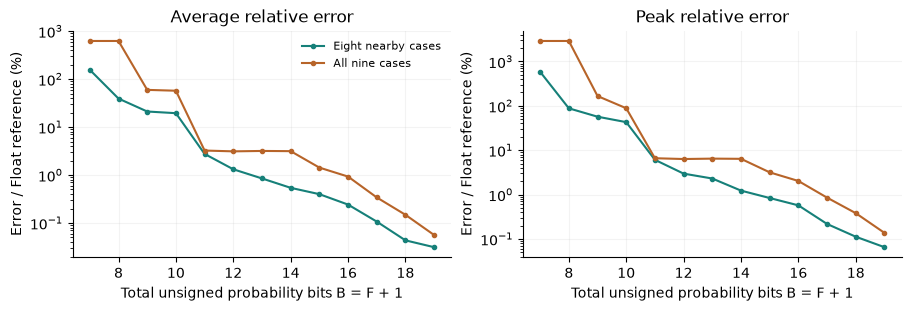

In [8]:
fig_bits, axes = plt.subplots(1, 2, figsize=(9, 3.0), layout="constrained")

nearby = []
for workload in workloads[:8]:
    nearby.append(workload["name"])

plot_sets = [
    (nearby, "#168079", "Eight nearby cases"),
    (None, "#b76429", "All nine cases"),
]
metrics = ["avg_relative", "peak_relative"]
titles = ["Average relative error", "Peak relative error"]

for axis_index in range(len(axes)):
    axis = axes[axis_index]
    metric = metrics[axis_index]
    for names, color, label in plot_sets:
        code_bits = []
        plotted_errors = []
        for fractional_bits in range(6, 19):
            code_bits.append(fractional_bits + 1)
            plotted_errors.append(aggregate(fractional_bits, names=names)[metric])
        axis.semilogy(
            code_bits,
            plotted_errors,
            "o-",
            color=color,
            ms=3,
            label=label,
        )
    axis.set(
        title=titles[axis_index],
        xlabel="Total unsigned probability bits B = F + 1",
        ylabel="Error / Float reference (%)",
    )
    axis.grid(alpha=0.15)

axes[0].legend(frameon=False, fontsize=8)
plt.show()

Read the graph: the horizontal axis is total stored bits, B=F+1. The vertical axis is error (%), on a scale that increases by factors of ten.

For each precision, first calculate the average and peak separately for every case. Within each plotted set, show the largest of the case averages and the largest of the case peaks. They may come from different cases. The plot shows F=6 through 18; the tables include all tested settings.

The next table highlights representative widths and their measured errors, so the cost of extra precision is easy to compare. The full binary table follows, then the decimal table.

In [9]:
binary_summary = []
for fractional_bits in range(19):
    metrics = aggregate(fractional_bits)
    row = {"F": fractional_bits, "B": fractional_bits + 1}
    row.update(metrics)
    binary_summary.append(row)

decimal_summary = []
for decimal_places in range(7):
    scale = 10 ** decimal_places
    metrics = aggregate(decimal_places, family="decimal")
    row = {"digits": decimal_places, "B": scale.bit_length()}
    row.update(metrics)
    decimal_summary.append(row)

choices = []
choice_specs = [
    ("Eight nearby", nearby, 12),
    ("All nine", None, 14),
    ("All nine", None, 15),
    ("All nine", None, 16),
]
for scope, names, fractional_bits in choice_specs:
    metrics = aggregate(fractional_bits, names=names)
    choice = {"scope": scope, "F": fractional_bits, "B": fractional_bits + 1}
    choice.update(metrics)
    choices.append(choice)

show_records(
    choices,
    ["scope", "F", "B", "avg_relative", "peak_relative"],
    headers=["Workload set", "Fractional bits F", "Total code bits B", "Average %", "Peak %"],
    title="Representative binary settings, using nearest rounding",
)
show_records(
    binary_summary,
    ["F", "B", "avg_relative", "peak_relative", "avg_initial", "peak_initial"],
    headers=["Fractional F", "Total B", "Relative average %", "Relative peak %", "Initial-N average %", "Initial-N peak %"],
    title="Every binary precision: largest per-case errors across all nine cases",
)
show_records(
    decimal_summary,
    ["digits", "B", "avg_relative", "peak_relative"],
    headers=["Decimal places", "Total code bits", "Relative average %", "Relative peak %"],
    title="Every decimal precision: nearest rounding, all nine cases",
)


Representative binary settings, using nearest rounding
Workload set | Fractional bits F | Total code bits B | Average % | Peak %
Eight nearby | 12                | 13                | 0.849     | 2.300 
All nine     | 14                | 15                | 1.429     | 3.169 
All nine     | 15                | 16                | 0.928     | 2.025 
All nine     | 16                | 17                | 0.341     | 0.853 

Every binary precision: largest per-case errors across all nine cases
Fractional F | Total B | Relative average % | Relative peak % | Initial-N average % | Initial-N peak %
0            | 1       | 717.107            | 4676.737        | 48.950              | 99.996          
1            | 2       | 717.107            | 4676.737        | 48.950              | 99.996          
2            | 3       | 717.107            | 4676.737        | 48.950              | 99.996          
3            | 4       | 717.107            | 4676.737        | 48.950              | 99.99

### Why fewer decimal values can give smaller summary errors

Binary F=15 has spacing 1/32768, about 0.00003052. Four decimal places have spacing 1/10000 = 0.0001. Binary has finer spacing and a smaller maximum possible rounding error for a single probability. However, these grids do not contain the same points: a particular probability can lie closer to a decimal point.

The code below reads existing experiment results and works through one stored probability. It does not add another experiment. In the smallest-step case, one conditional chance is 0.9990030035. Binary F=15 stores 0.9989929199; four decimals store 0.9990000000, which is closer. This is one illustration, not the only probability that matters. All stored choices affect the final populations, and their errors can reinforce or partly cancel over repeated steps.

Binary F=15 has smaller average and peak errors in eight of nine cases. The smallest-step case reverses that comparison and sets both binary maxima. Decimal's largest average comes from the smallest step, but its largest peak comes from the half-time-step case. Thus the decimal summary does not mean that decimal wins in every case or in general.

For other binary choices, F=14 gives largest average / peak errors of 1.429% / 3.169%, and F=16 gives 0.341% / 0.853%. Four decimal places give 0.631% / 1.443%; five give 0.366% / 0.801%. Use the measured results for the cases you need. Storage counts describe the probability code, not total hardware cost.

An error above 100% is possible when coarse rounding leaves many walkers while Float predicts few. A finer grid need not reduce every final population error because several rounded choices act together.

### Why the rounding rule must be stated

Nearest rounding chooses the closest code. Truncation rounds down. The table after the worked comparison shows both rules across all nine cases.

In [10]:
# Reuse the existing results; compare the two grids case by case.
comparison_rows = []
binary_wins = 0
for workload in workloads:
    name = workload["name"]
    binary = aggregate(15, names=[name])
    decimal = aggregate(4, family="decimal", names=[name])
    comparison_rows.append([
        name, binary["avg_relative"], binary["peak_relative"],
        decimal["avg_relative"], decimal["peak_relative"],
    ])
    if (binary["avg_relative"] < decimal["avg_relative"]
            and binary["peak_relative"] < decimal["peak_relative"]):
        binary_wins += 1
show_table(
    ["Case", "F15 average %", "F15 peak %", "Decimal-4 average %", "Decimal-4 peak %"],
    comparison_rows,
)
print(f"Binary F=15 is better on both metrics in {binary_wins} of 9 cases.")

# Second conditional choice from direction 1 in the smallest-step case.
small_step_matrix = transport_matrix(dt=0.0005)
row = small_step_matrix[1]
q = float(row[1] / math.fsum(row[1:]))
print(f"Original conditional probability: {q:.10f}")
for label, scale in [("Binary F15", 2**15), ("Decimal 4", 10**4)]:
    code, stored_q = round_probability(q, scale)
    print(f"{label}: {stored_q:.10f}; absolute error {abs(stored_q - q):.10f}")

rounding_rows = []
for fractional_bits in (10, 12, 14, 15, 16, 18):
    row = [fractional_bits]
    for mode in ("nearest", "truncate"):
        metrics = aggregate(fractional_bits, mode=mode)
        row.extend([metrics["avg_relative"], metrics["peak_relative"]])
    rounding_rows.append(row)

show_table(
    ["Fractional bits F", "Nearest average %", "Nearest peak %", "Truncate average %", "Truncate peak %"],
    rounding_rows,
)

Case                   | F15 average % | F15 peak % | Decimal-4 average % | Decimal-4 peak %
Tutorial               | 0.057         | 0.131      | 0.088               | 0.190           
Half scattering        | 0.025         | 0.060      | 0.035               | 0.081           
Double scattering      | 0.028         | 0.071      | 0.123               | 0.299           
Half absorption        | 0.147         | 0.349      | 0.431               | 0.886           
Double absorption      | 0.031         | 0.069      | 0.123               | 0.307           
Half time step         | 0.242         | 0.571      | 0.581               | 1.443           
Double time step       | 0.030         | 0.066      | 0.104               | 0.222           
All in direction 0     | 0.050         | 0.123      | 0.108               | 0.206           
Ten-times smaller step | 0.928         | 2.025      | 0.631               | 1.282           
Binary F=15 is better on both metrics in 8 of 9 cases.
Original condit

## 6. Read an expected output example

The next table uses the original tutorial at time 2, after 400 steps. “Direction 0” and “Direction 1” are expected walker counts; “Total live” is their sum. The two flux columns divide the corresponding counts by 60.
This shows what the precision changes mean in actual output values, alongside the error percentages.

In [11]:
output_examples = []
output_time = 2.0
output_steps = round(output_time / dt)  # 400 steps with dt=0.005.
output_settings = [
    ("Float", None),
    ("F=0", 2**0),
    ("F=8", 2**8),
    ("F=12", 2**12),
    ("F=16", 2**16),
]
for label, scale in output_settings:
    rounded_probabilities, _ = rounded_matrix(P, scale)
    final_counts = expectation(rounded_probabilities, initial, output_steps)[-1]
    output_examples.append({
        "setting": label,
        "direction0": float(final_counts[0]),
        "direction1": float(final_counts[1]),
        "live": float(final_counts[:2].sum()),
        "flux0": float(final_counts[0] / 60),
        "flux1": float(final_counts[1] / 60),
    })

show_records(
    output_examples,
    ["setting", "direction0", "direction1", "live", "flux0", "flux1"],
    headers=["Setting", "Direction 0 walkers", "Direction 1 walkers", "Total live", "Direction 0 flux", "Direction 1 flux"],
)

Setting | Direction 0 walkers | Direction 1 walkers | Total live | Direction 0 flux | Direction 1 flux
Float   | 5.246               | 5.246               | 10.492     | 0.087            | 0.087           
F=0     | 300.000             | 180.000             | 480.000    | 5.000            | 3.000           
F=8     | 8.371               | 8.128               | 16.499     | 0.140            | 0.135           
F=12    | 5.173               | 5.165               | 10.338     | 0.086            | 0.086           
F=16    | 5.255               | 5.255               | 10.510     | 0.088            | 0.088           


What this shows: Float predicts about 10.492 walkers remaining in total. F=0 rounds away the chance of loss and leaves all 480 trapped. F=12 predicts 10.338 and F=16 predicts 10.510, close to Float.

The fractional counts are averages of possible populations, not fractional walkers in a run. Counts below 10 are displayed here even though the relative-error summaries exclude them. The error divided by initial population includes them.

## 7. Does a longer run need more precision?

Keep the original probabilities, time step and 480 walkers. Change only when the calculation stops.
The next table shows F=12 and F=16 with nearest rounding; all 25 duration comparisons are available at the end.

For each stopping time, calculate Float once, then compare each rounded version against it. Save all five precisions and show F=12 and F=16 in the compact table.

In [12]:
duration_results = []
duration_table = []
horizons = (0.25, 0.5, 1.0, 2.0, 5.0)

for horizon in horizons:
    rounds = round(horizon / dt)
    reference = expectation(P, initial, rounds)
    row = [horizon]

    for fractional_bits in (8, 10, 12, 14, 16):
        rounded_probabilities, _ = rounded_matrix(P, 2**fractional_bits)
        rounded_counts = expectation(rounded_probabilities, initial, rounds)
        metrics = errors(rounded_counts, reference, live_directions, total=480)
        result = {"time": horizon, "F": fractional_bits}
        result.update(metrics)
        duration_results.append(result)

        # Save all results; show just F12 and F16 in the compact table.
        if fractional_bits in (12, 16):
            row.extend([metrics["avg_relative"], metrics["peak_relative"]])
    duration_table.append(row)

show_table(
    ["Physical time", "F12 average %", "F12 peak %", "F16 average %", "F16 peak %"],
    duration_table,
)

Physical time | F12 average % | F12 peak % | F16 average % | F16 peak %
0.250         | 0.085         | 0.227      | 0.009         | 0.023     
0.500         | 0.174         | 0.424      | 0.020         | 0.045     
1.000         | 0.357         | 0.799      | 0.041         | 0.088     
2.000         | 0.602         | 1.289      | 0.069         | 0.145     
5.000         | 0.602         | 1.289      | 0.069         | 0.145     


What this shows: more steps can accumulate more rounding error. The equal values at times 2 and 5 do not prove that later error stops growing. Those later Float counts are below 10, so this relative percentage excludes them.
The error divided by initial population includes all later times and is available in the complete duration table.

## 8. Do more walkers need more probability precision?

Use 48, 480 or 4,800 walkers with the original 5:3 directional split and stop at time 5. Keep the probabilities unchanged.

Multiplying the population by ten multiplies both the absolute rounding error and the Float count by ten. Dividing one by the other gives the same percentage. Scale the comparison cutoff too, from 1 to 10 to 100, so each calculation covers the same part of its curve.

Expected result: the probability-rounding percentages should match. Larger counts still need enough integer range, but increasing population alone does not add a need for fractional probability bits in this experiment.

The loop handles one starting population at a time. It calculates Float once, compares the two precisions, and adds the results to the table.

In [13]:
population_bias = []
population_table = []
population_starts = [
    np.array([30, 18, 0]),
    initial,
    np.array([3000, 1800, 0]),
]
population_steps = round(stopping_time / dt)  # Original model, run to time 5.

for start in population_starts:
    total = int(start.sum())
    reference = expectation(P, start, population_steps)
    row = [total, total / 48]

    for fractional_bits in (12, 16):
        rounded_probabilities, _ = rounded_matrix(P, 2**fractional_bits)
        rounded_counts = expectation(rounded_probabilities, start, population_steps)
        metrics = errors(rounded_counts, reference, live_directions, total)
        result = {"walkers": total, "F": fractional_bits}
        result.update(metrics)
        population_bias.append(result)
        row.extend([metrics["avg_relative"], metrics["peak_relative"]])
    population_table.append(row)

show_table(
    ["Initial walkers", "Reference cutoff", "F12 avg %", "F12 peak %", "F16 avg %", "F16 peak %"],
    population_table,
)

Initial walkers | Reference cutoff | F12 avg % | F12 peak % | F16 avg % | F16 peak %
48              | 1.000            | 0.602     | 1.289      | 0.069     | 0.145     
480             | 10.000           | 0.602     | 1.289      | 0.069     | 0.145     
4800            | 100.000          | 0.602     | 1.289      | 0.069     | 0.145     


## 9. Final result: binary fixed-point choices

All rows below use nearest rounding and the same fractional precision for each stored probability. Bits are per probability code and include the endpoint 1.

| Tested cases | Fractional bits F | Stored bits B | Largest average / peak error |
|---|---:|---:|---|
| Eight nearby cases | 12 | 13 | 0.849% / 2.300% |
| All nine cases | 14 | 15 | 1.429% / 3.169% |
| All nine cases | 15 | 16 | 0.928% / 2.025% |
| All nine cases | 16 | 17 | 0.341% / 0.853% |

For the full test set, F=15 is a useful starting point: store T = floor(32768*q + 0.5) in 16 bits and interpret it as probability T/32768. F=16 reduces the measured errors further at the cost of one additional stored bit. F=14 gives a smaller code with larger errors. There is no single minimum without choosing how much error is acceptable; the table makes that decision explicit.

The smaller F=12 result applies only to the eight nearby cases. The small-step stress case needs more precision for comparable errors. Increasing the initial population alone does not change the expected percentage bias, while changing probabilities or the number of steps can change it.

These conclusions concern the listed cases and the stated comparison cutoff, not every input between their endpoints. Initial-population-normalized results below include the late-time tail. Individual random runs can differ. The study establishes the numerical effect of fixed-point probability codes; hardware implementation and integer-state sizing are separate tasks.

Decimal rounding remains a comparison baseline. Four places use 14 code bits and give largest average / peak errors of 0.631% / 1.443% in these tests. That result does not replace the binary fixed-point conclusion or establish a hardware format.

### Complete numerical results

The tables below list all 52 combinations of precision and rounding rule for each case. "Relative" divides by the Float count when it is at or above the cutoff; "initial" divides by the starting population and includes all times. Displayed values have three decimal places, so 0.000 can mean a smaller nonzero error.

In [14]:
precision_columns = [
    "family",
    "precision",
    "total_bits",
    "rounding",
    "avg_relative",
    "peak_relative",
    "avg_initial",
    "peak_initial",
]
precision_headers = [
    "Grid",
    "F or decimals",
    "Total code bits",
    "Rounding",
    "Average relative %",
    "Peak relative %",
    "Average / initial %",
    "Peak / initial %",
]
for workload in workloads:
    workload_precision = []
    for result in precision_results:
        if result["case"] == workload["name"]:
            workload_precision.append(result)
    show_records(
        workload_precision,
        precision_columns,
        headers=precision_headers,
        title="All 52 results: " + workload["name"],
    )

show_records(
    duration_results,
    ["time", "F", "avg_relative", "peak_relative", "avg_initial", "peak_initial"],
    headers=["Time", "Fractional bits", "Average relative %", "Peak relative %", "Average / initial %", "Peak / initial %"],
    title="All duration results",
)
show_records(
    population_bias,
    ["walkers", "F", "avg_relative", "peak_relative", "avg_initial", "peak_initial"],
    headers=["Walkers", "Fractional bits", "Average relative %", "Peak relative %", "Average / initial %", "Peak / initial %"],
    title="Population scaling: expected bias is unchanged",
)


All 52 results: Tutorial
Grid    | F or decimals | Total code bits | Rounding | Average relative % | Peak relative % | Average / initial % | Peak / initial %
binary  | 0             | 1               | nearest  | 622.396            | 2885.466        | 44.753              | 62.496          
binary  | 0             | 1               | truncate | 99.700             | 100.000         | 5.201               | 61.430          
binary  | 1             | 2               | nearest  | 622.396            | 2885.466        | 44.753              | 62.496          
binary  | 1             | 2               | truncate | 99.146             | 100.000         | 5.120               | 55.568          
binary  | 2             | 3               | nearest  | 622.396            | 2885.466        | 44.753              | 62.496          
binary  | 2             | 3               | truncate | 98.272             | 100.000         | 4.988               | 49.684          
binary  | 3             | 4               |

### Source and reproduction

The model formula and initial conditions come from `Sango-Brian2-RandomWalker/random_walker_brian2_tutorial.ipynb`. Conditional choices retain the original destination order. This notebook computes the expected populations independently with NumPy.

To examine another input range, edit the case list or stopping times and select Restart Kernel and Run All Cells. Keep the error denominator and cutoff explicit so the new percentages remain interpretable.

The small-step experiment compares rounding against Float at that same small step. It does not compare different time steps against each other or test the accuracy of the continuous-physics approximation.

All 14 code cells were executed successfully from a fresh kernel on 6 October 2026. The saved outputs contain 468 precision comparisons, 25 duration comparisons, 6 population comparisons and 5 output examples.